In [5]:
# Covid Hackathon
import pandas as pd
import numpy as np

data = pd.read_csv("data/corona_tested_individuals_ver_006.csv")
data.head()

C:\Users\jonesp34\AppData\Local\Temp\3\ipykernel_27932\1782621411.py:5: DtypeWarning: Columns (0: age_60_and_above) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data/corona_tested_individuals_ver_006.csv")


,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,30/04/2020,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
1,30/04/2020,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
2,30/04/2020,0.0,1.0,0.0,0.0,0.0,negative,NaN,male,Other
3,30/04/2020,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
4,30/04/2020,1.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 278848 entries, 0 to 278847
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   test_date            278848 non-null  str    
 1   cough                278596 non-null  float64
 2   fever                278596 non-null  float64
 3   sore_throat          278847 non-null  float64
 4   shortness_of_breath  278847 non-null  float64
 5   head_ache            278847 non-null  float64
 6   corona_result        278848 non-null  str    
 7   age_60_and_above     151528 non-null  str    
 8   gender               259285 non-null  str    
 9   test_indication      278848 non-null  str    
dtypes: float64(5), str(5)
memory usage: 21.3 MB


In [7]:
data.shape

(278848, 10)

In [8]:
# Delete columns where corona_result is other, since this will not add meaningful information
# to the model
# Also created new dataframe "df" to avoid corrupting original "data0 file"
df = data[data["corona_result"] != "other"]
df.shape

(274956, 10)

In [9]:
# Data should be int, float or bool
# Corona result, age, gender and test indication are string
# test_date is also string, but will be dropped

# convert corona_result to 0, 1
df["corona_result"] = df["corona_result"].map({
    "negative": 0,
    "positive": 1
})

# convert age, gender and test indication to category - not boolean because of missing values
df[['gender', 'age_60_and_above', 'test_indication']] = df[['gender', 'age_60_and_above', 'test_indication']].astype('category')

df.info()

<class 'pandas.DataFrame'>
Index: 274956 entries, 0 to 278847
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   test_date            274956 non-null  str     
 1   cough                274704 non-null  float64 
 2   fever                274704 non-null  float64 
 3   sore_throat          274955 non-null  float64 
 4   shortness_of_breath  274955 non-null  float64 
 5   head_ache            274955 non-null  float64 
 6   corona_result        274956 non-null  int64   
 7   age_60_and_above     149292 non-null  category
 8   gender               255911 non-null  category
 9   test_indication      274956 non-null  category
dtypes: category(3), float64(5), int64(1), str(1)
memory usage: 17.6 MB


In [10]:
df_1hot = pd.get_dummies(
df,
columns=["test_indication"],
prefix="test_indication"
)

df_1hot.head()

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication_Abroad,test_indication_Contact with confirmed,test_indication_Other
0,30/04/2020,0.0,0.0,0.0,0.0,0.0,0,NaN,female,False,False,True
1,30/04/2020,1.0,0.0,0.0,0.0,0.0,0,NaN,female,False,False,True
2,30/04/2020,0.0,1.0,0.0,0.0,0.0,0,NaN,male,False,False,True
3,30/04/2020,1.0,0.0,0.0,0.0,0.0,0,NaN,female,False,False,True
4,30/04/2020,1.0,0.0,0.0,0.0,0.0,0,NaN,male,False,False,True


In [11]:
# Ignore 1-hot encoding at this stage
# Try LightGBM model first

# Drop test_date since this will not be used in first model
df = df.drop(columns=["test_date"])
df.head()

,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,0.0,0.0,0.0,0.0,0.0,0,NaN,female,Other
1,1.0,0.0,0.0,0.0,0.0,0,NaN,female,Other
2,0.0,1.0,0.0,0.0,0.0,0,NaN,male,Other
3,1.0,0.0,0.0,0.0,0.0,0,NaN,female,Other
4,1.0,0.0,0.0,0.0,0.0,0,NaN,male,Other


In [12]:
# Create test-train data
from sklearn.model_selection import train_test_split

X = df.drop('corona_result', axis=1)
y = df.corona_result

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=24)

In [13]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

corona_result
0    0.94643
1    0.05357
Name: proportion, dtype: float64
corona_result
0    0.946435
1    0.053565
Name: proportion, dtype: float64


In [ ]:
# Distribution looks OK

In [14]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 206217 entries, 185297 to 127363
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   cough                206019 non-null  float64 
 1   fever                206020 non-null  float64 
 2   sore_throat          206216 non-null  float64 
 3   shortness_of_breath  206216 non-null  float64 
 4   head_ache            206216 non-null  float64 
 5   age_60_and_above     112003 non-null  category
 6   gender               191940 non-null  category
 7   test_indication      206217 non-null  category
dtypes: category(3), float64(5)
memory usage: 10.0 MB


In [15]:
# Correct cols and datatypes
# Now try LightGBM
import lightgbm as lgb

lgb_train = lgb.Dataset(X_train, y_train)
lgb_test = lgb.Dataset(X_test, y_test, reference=lgb_train)


In [16]:
params = {
    'boosting_type': 'gbdt',
    'objective': 'binary',
    'metric': 'binary_logloss',
    'num_leaves': 31,
    'learning_rate': 0.1,
    'max_depth': -1,
    'verbose': 0,
    'seed': 0
}

[10]	train's binary_logloss: 0.116351
[20]	train's binary_logloss: 0.106911
[30]	train's binary_logloss: 0.104605
[40]	train's binary_logloss: 0.103656
[50]	train's binary_logloss: 0.103216
[60]	train's binary_logloss: 0.102996
[70]	train's binary_logloss: 0.102858
[80]	train's binary_logloss: 0.102762
[90]	train's binary_logloss: 0.102691
[100]	train's binary_logloss: 0.102638


<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='binary_logloss'>

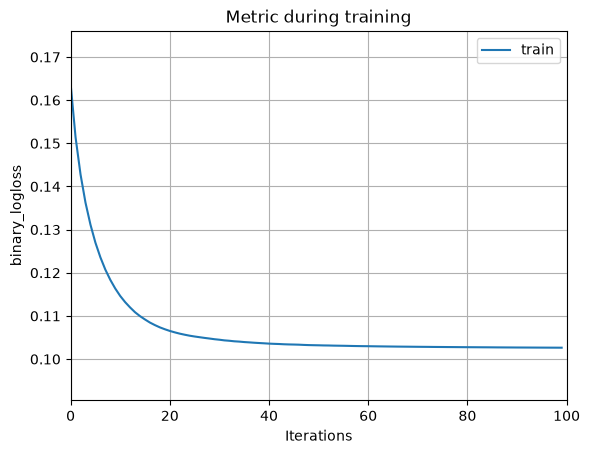

In [17]:
import matplotlib.pyplot as plt

evals={}

model = lgb.train(params=params,
                  train_set=lgb_train,
                  valid_sets=[lgb_train],
                  valid_names=['train'],
                  callbacks=[lgb.record_evaluation(evals),lgb.log_evaluation(10)]
                  )

lgb.plot_metric(evals)


In [18]:
def train_model(params):

    evals ={}

    lgb_train = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
    lgb_valid = lgb.Dataset(X_test, label=y_test, reference=lgb_train, free_raw_data=False)

    model = lgb.train(
        params=params,
        train_set=lgb_train,
        num_boost_round=1000,
        valid_sets=[lgb_train, lgb_valid],
        valid_names=['seen', 'unseen'],
        callbacks=[
            lgb.record_evaluation(evals), lgb.early_stopping(first_metric_only=True, stopping_rounds=20, verbose=True),
        ]
    )

    return model, evals

[LightGBM] [Info] Number of positive: 11047, number of negative: 195170
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003879 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 25
[LightGBM] [Info] Number of data points in the train set: 206217, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.053570 -> initscore=-2.871712
[LightGBM] [Info] Start training from score -2.871712
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='binary_logloss'>

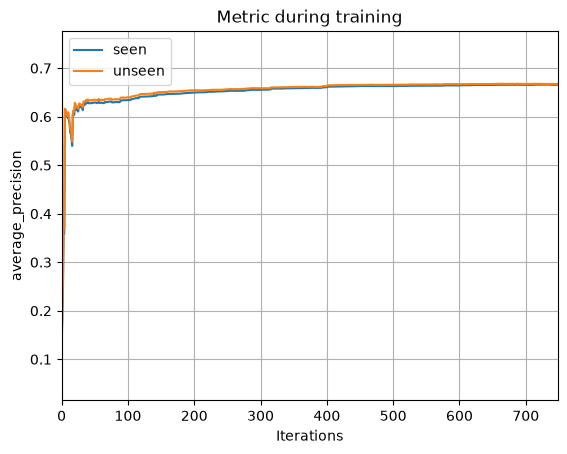

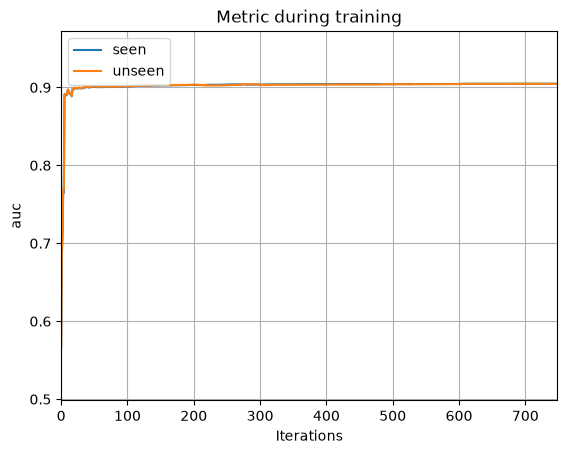

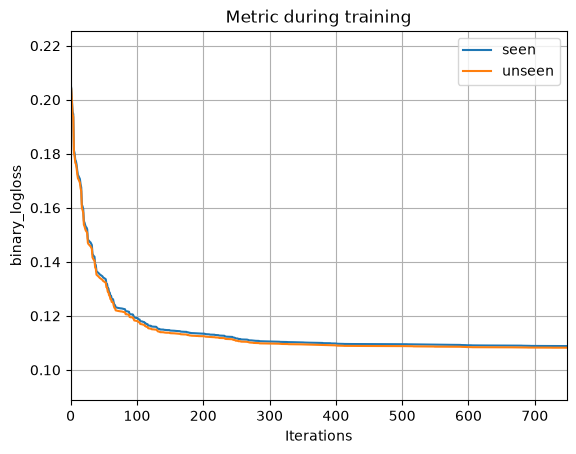

In [19]:
# Pamas used in the paper by Zoabi et al
paper_params = {
    'boosting_type': 'gbdt',
    'objective': 'binary',
    'metric': ['binary_logloss','auc','average_precision'],
    'feature_pre_filter': False,
    'num_leaves': 20,
    'min_data_in_leaf': 4,
    'feature_fraction': 0.2,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'learning_rate': 0.05,
    'verbose': 1,
}


model2, evals2 = train_model(paper_params)

lgb.plot_metric(evals2, metric='average_precision')
lgb.plot_metric(evals2, metric='auc')
lgb.plot_metric(evals2, metric='binary_logloss')

[LightGBM] [Info] Number of positive: 11047, number of negative: 195170
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002878 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 25
[LightGBM] [Info] Number of data points in the train set: 206217, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.053570 -> initscore=-2.871712
[LightGBM] [Info] Start training from score -2.871712
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 20 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='binary_logloss'>

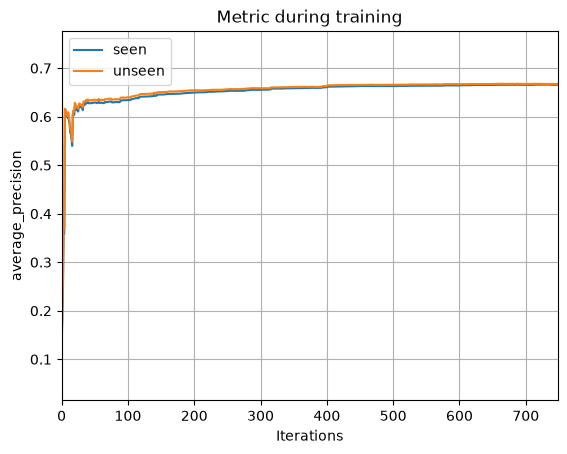

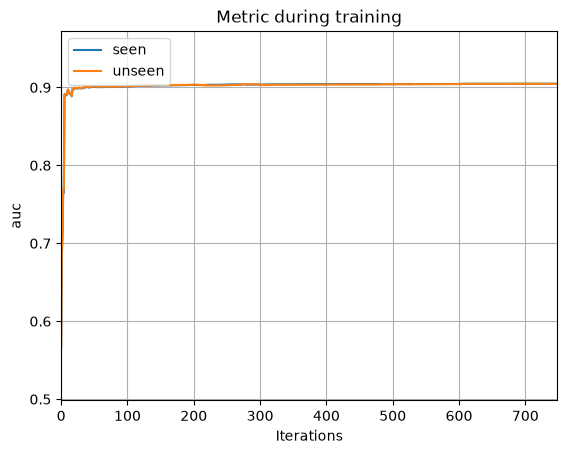

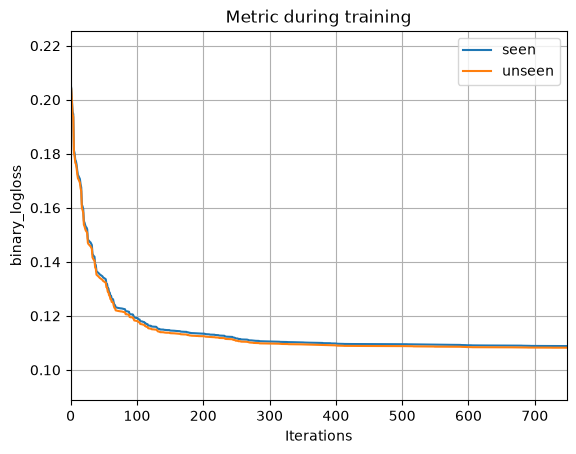

In [20]:
# Adding other metrics - auc , av_precision

paper_params2 = {
    'boosting_type': 'gbdt',
    'objective': 'binary',
    'metric': ['binary_logloss','auc','average_precision'],
    'feature_pre_filter': False,
    'num_leaves': 20,
    'min_data_in_leaf': 4,
    'feature_fraction': 0.2,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'learning_rate': 0.05,
    'verbose': 1,
}

model3, evals3 = train_model(paper_params2)

lgb.plot_metric(evals3, metric='average_precision')
lgb.plot_metric(evals3, metric='auc')
lgb.plot_metric(evals3, metric='binary_logloss')



In [74]:
pd.DataFrame(model3.best_score).T

,binary_logloss,auc,average_precision
seen,0.108838,0.904752,0.666007
unseen,0.108228,0.904666,0.667433


In [75]:
pd.DataFrame(model2.best_score).T

,binary_logloss,auc,average_precision
seen,0.108838,0.904752,0.666007
unseen,0.108228,0.904666,0.667433


In [21]:
#parameter search
# create confusion matrix + ROC-AUC curve
# pkl file for best model

from sklearn.model_selection import GridSearchCV

param_grid = {
    'num_leaves': [10, 20, 30, 40],
    'min_child_samples': [2, 4, 8, 16],
    'colsample_bytree': [0.1, 0.2, 0.3, 0.5],
    'subsample': [0.6, 0.8, 1.0],
    'subsample_freq': [3, 5, 7],
    'learning_rate': [0.03, 0.05, 0.07]
}


In [22]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV

lgbm = LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    random_state=24,
    verbosity=-1
)

search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    random_state=24,
    n_jobs=-1,
    verbose=2
)

search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie... verbosity=-1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.1, 0.2, ...], 'learning_rate': [0.03, 0.05, ...], 'min_child_samples': [2, 4, ...], 'num_leaves': [10, 20, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",24
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a functio

In [23]:
print(search.best_params_)
print(search.best_score_)

{'subsample_freq': 7, 'subsample': 1.0, 'num_leaves': 30, 'min_child_samples': 4, 'learning_rate': 0.07, 'colsample_bytree': 0.5}
0.9067959038579956


In [25]:
#try broader search
param_grid_broad = {
    'num_leaves': [5, 10, 20, 40, 80, 160],
    'min_child_samples': [1, 2, 4, 8, 16, 32, 64],
    'learning_rate': [0.005, 0.01, 0.02, 0.05, 0.1],
    'colsample_bytree': [0.1, 0.2, 0.4, 0.6, 0.8, 1.0],
    'subsample': [0.4, 0.6, 0.8, 1.0],
    'subsample_freq': [1, 3, 5, 10],
    'reg_alpha': [0, 0.01, 0.1, 1, 10],
    'reg_lambda': [0, 0.01, 0.1, 1, 10]
}

In [26]:
lgbm = LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    random_state=24,
    verbosity=-1
)

search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid_broad,
    n_iter=250,
    scoring='roc_auc',
    cv=5,
    random_state=24,
    n_jobs=-1,
    verbose=4
)

search.fit(X_train, y_train)

Fitting 5 folds for each of 250 candidates, totalling 1250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie... verbosity=-1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.1, 0.2, ...], 'learning_rate': [0.005, 0.01, ...], 'min_child_samples': [1, 2, ...], 'num_leaves': [5, 10, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",250
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",4
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",24
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a functi

In [ ]:
# Print best hyperparameters and scores
print(f"Best hyperparameters: {search.best_params_}")
print(f"Best model accuracy: {search.best_score_}")

best_model = search.best_estimator_

print(f"Accuracy on seen data: {best_model.score(X_train, y_train)}")
print(f"Accuracy on unseen data: {best_model.score(X_test, y_test)}")

Best hyperparameters: {'subsample_freq': 3, 'subsample': 0.4, 'reg_lambda': 1, 'reg_alpha': 0, 'num_leaves': 160, 'min_child_samples': 16, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best model accuracy: 0.9090093913965751
Accuracy on seen data: 0.969823050475955
Accuracy on unseen data: 0.9701188553804972


In [ ]:
# work out what are the most important features of the model
best_model.importance_type

'split'

In [30]:
#Createa df to show feature importance
f_imp = pd.DataFrame(dict(feature=best_model.feature_name_, importance=best_model.feature_importances_))

f_imp = f_imp.sort_values('importance', ascending=False)
f_imp

,feature,importance
6,gender,1115
5,age_60_and_above,917
7,test_indication,560
0,cough,518
2,sore_throat,472
1,fever,445
3,shortness_of_breath,334
4,head_ache,325


Classification report: unseen data

              precision    recall  f1-score   support

    Negative     0.9768    0.9920    0.9843     65057
    Positive     0.8044    0.5842    0.6768      3682

    accuracy                         0.9701     68739
   macro avg     0.8906    0.7881    0.8306     68739
weighted avg     0.9676    0.9701    0.9679     68739



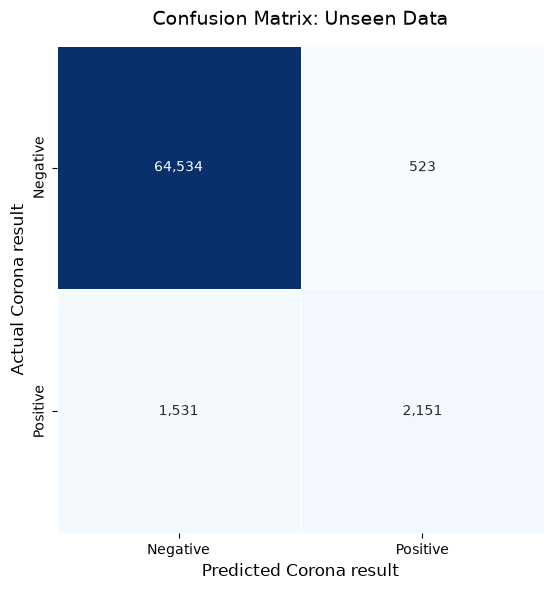

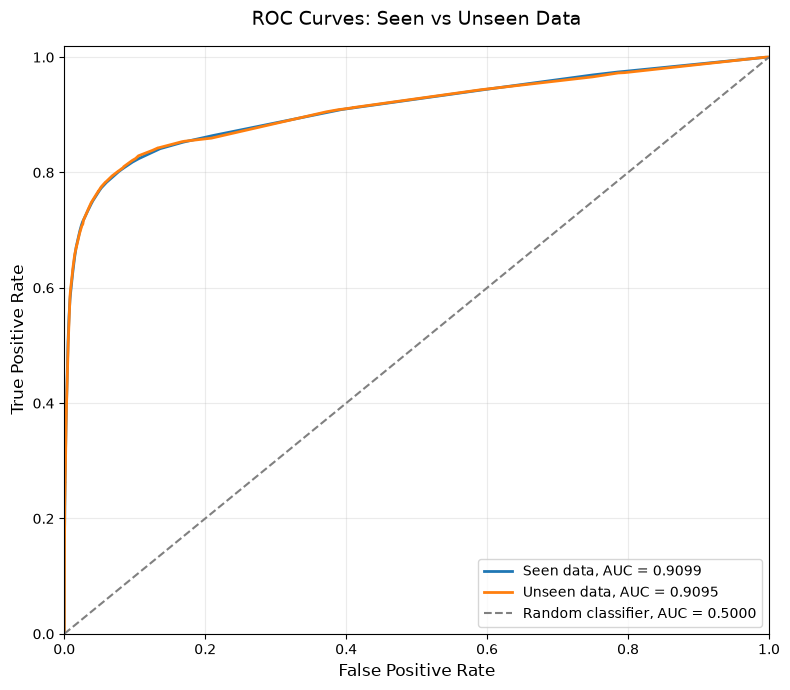

,Dataset,ROC AUC
0,Seen,0.9099
1,Unseen,0.9095


In [31]:
# print confusion-matrix
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# Generate class predictions for confusion matrix
best_model_pred = best_model.predict(X_test)

# Generate probabilities for ROC-AUC curves

# Probability of the positive class, corona_result = 1
y_train_probability = best_model.predict_proba(X_train)[:, 1]
y_test_probability = best_model.predict_proba(X_test)[:, 1]

# Print classification report

print("Classification report: unseen data\n")

print(
    classification_report(
        y_test,
        best_model_pred,
        target_names=["Negative", "Positive"],
        digits=4,
        zero_division=0
    )
)

# Create labelled confusion-matrix heatmap

cm = confusion_matrix(
    y_test,
    best_model_pred,
    labels=[0, 1]
)

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    square=True,
    linewidths=0.5,
    linecolor="white",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    ax=ax
)

ax.set_title(
    "Confusion Matrix: Unseen Data",
    fontsize=14,
    pad=15
)

ax.set_xlabel(
    "Predicted Corona result",
    fontsize=12
)

ax.set_ylabel(
    "Actual Corona result",
    fontsize=12
)

plt.tight_layout()
plt.show()

# Calculate ROC curves for seen and unseen data

train_fpr, train_tpr, train_thresholds = roc_curve(
    y_train,
    y_train_probability
)

test_fpr, test_tpr, test_thresholds = roc_curve(
    y_test,
    y_test_probability
)

train_auc = roc_auc_score(
    y_train,
    y_train_probability
)

test_auc = roc_auc_score(
    y_test,
    y_test_probability
)

# Plot seen and unseen ROC curves

fig, ax = plt.subplots(figsize=(8, 7))

ax.plot(
    train_fpr,
    train_tpr,
    linewidth=2,
    label=f"Seen data, AUC = {train_auc:.4f}"
)

ax.plot(
    test_fpr,
    test_tpr,
    linewidth=2,
    label=f"Unseen data, AUC = {test_auc:.4f}"
)

# Random-classifier reference line
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    linewidth=1.5,
    label="Random classifier, AUC = 0.5000"
)

ax.set_title(
    "ROC Curves: Seen vs Unseen Data",
    fontsize=14,
    pad=15
)

ax.set_xlabel(
    "False Positive Rate",
    fontsize=12
)

ax.set_ylabel(
    "True Positive Rate",
    fontsize=12
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(loc="lower right")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Display AUC values as a table

auc_results = pd.DataFrame({
    "Dataset": ["Seen", "Unseen"],
    "ROC AUC": [train_auc, test_auc]
})

display(auc_results.round(4))

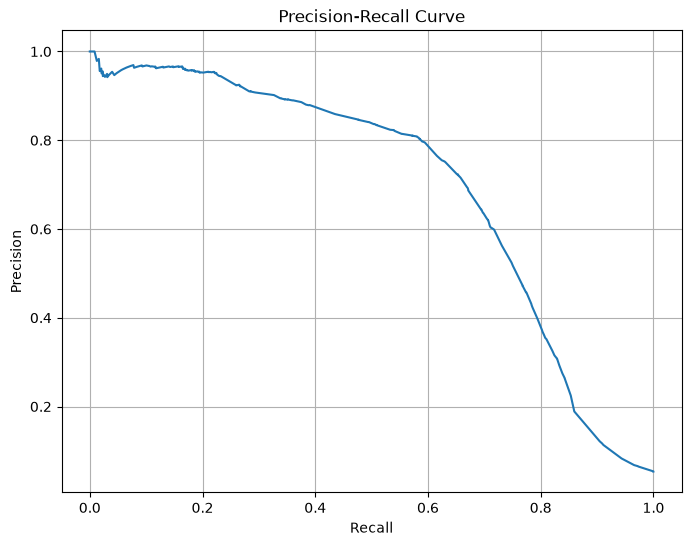

In [32]:
from sklearn.metrics import precision_recall_curve

proba = best_model.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(
    y_test,
    proba
)

plt.figure(figsize=(8,6))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.grid(True)

plt.show()

In [33]:
# Investigate precision-recall

for threshold in [0.5, 0.4, 0.3, 0.2]:

    pred = (proba >= threshold).astype(int)

    report = classification_report(
        y_test,
        pred,
        output_dict=True
    )

    print(
        f"Threshold={threshold:.1f} "
        f"Precision={report['1']['precision']:.3f} "
        f"Recall={report['1']['recall']:.3f}"
    )

Threshold=0.5 Precision=0.804 Recall=0.584
Threshold=0.4 Precision=0.765 Recall=0.616
Threshold=0.3 Precision=0.689 Recall=0.671
Threshold=0.2 Precision=0.636 Recall=0.698


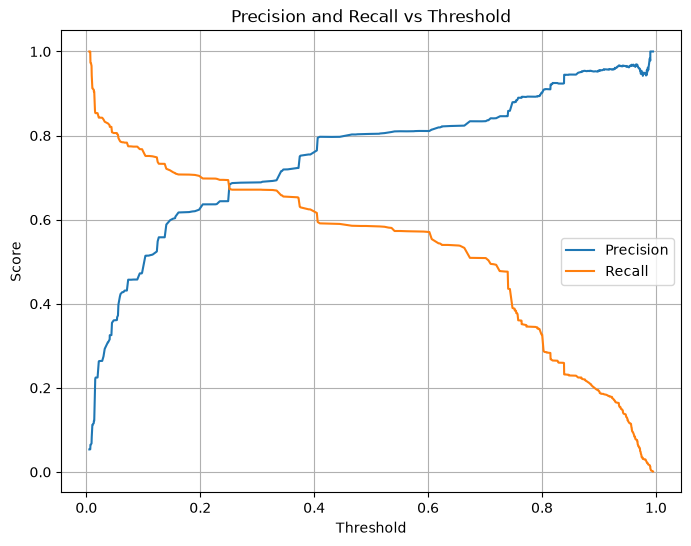

In [34]:
# plot threshold vs precision/recall
proba = best_model.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(
    y_test,
    proba
)

plt.figure(figsize=(8,6))

plt.plot(thresholds,
         precision[:-1],
         label='Precision')

plt.plot(thresholds,
         recall[:-1],
         label='Recall')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')

plt.legend()
plt.grid(True)

plt.show()

In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = best_model.predict_proba(X_test)[:,1]

results = []

for threshold in np.arange(0.05, 0.96, 0.05):

    pred = (proba >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred)
    })

results = pd.DataFrame(results)

results.round(3)

,threshold,precision,recall,f1
0,0.05,0.361,0.806,0.499
1,0.10,0.514,0.752,0.610
2,0.15,0.602,0.713,0.653
3,0.20,0.636,0.698,0.666
4,0.25,0.685,0.672,0.679
5,0.30,0.689,0.671,0.680
6,0.35,0.720,0.655,0.686
7,0.40,0.765,0.616,0.682
8,0.45,0.803,0.586,0.677
9,0.50,0.804,0.584,0.677


In [36]:
# Use threshold = 0.2 as best decision point
#Model 4: same LightGBM model, different operating threshold

threshold = 0.20

proba_test = best_model.predict_proba(X_test)[:,1]

model4_pred = (proba_test >= threshold).astype(int)

In [37]:
# Print classification report

print(
    classification_report(
        y_test,
        model4_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.98      0.98      0.98     65057
    Positive       0.64      0.70      0.67      3682

    accuracy                           0.96     68739
   macro avg       0.81      0.84      0.82     68739
weighted avg       0.96      0.96      0.96     68739



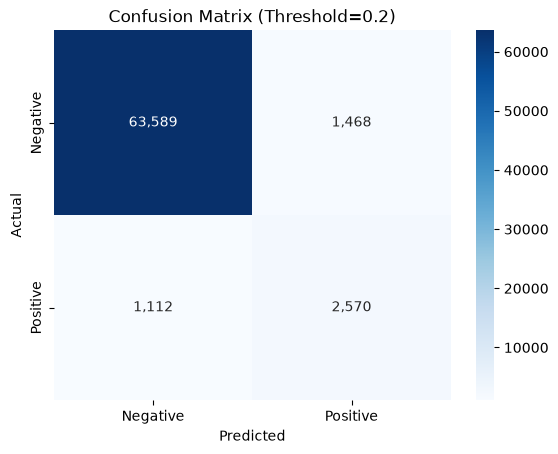

In [38]:
# Now repeat heatmap/confusion matrix
cm = confusion_matrix(y_test, model4_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt=",d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title(
    f"Confusion Matrix (Threshold={threshold})"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

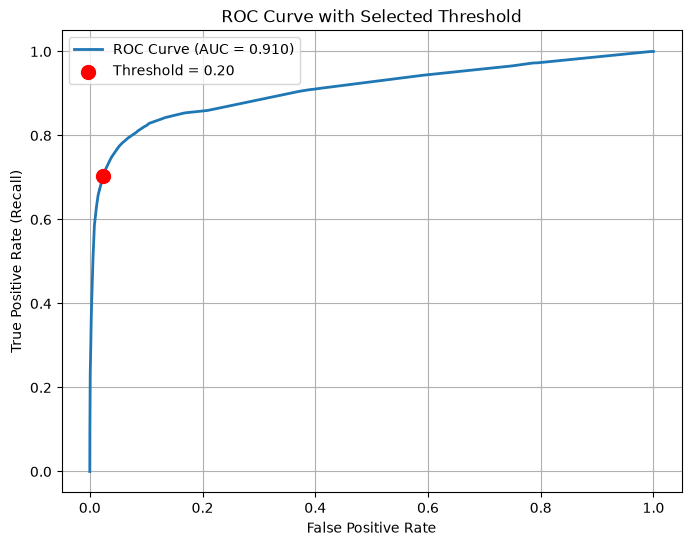

In [40]:
# Highlight threshold on ROC-AUC curve

# Probabilities
proba = best_model.predict_proba(X_test)[:,1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test,proba)

# Find threshold closest to 0.20
idx = np.argmin(np.abs(thresholds - 0.20))

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC Curve (AUC = {test_auc:.3f})"
)

# Plot selected operating point
plt.scatter(
    fpr[idx],
    tpr[idx],
    color="red",
    s=100,
    zorder=5,
    label=f"Threshold = {thresholds[idx]:.2f}"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve with Selected Threshold")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Create pickle file
import pickle

with open("lightgbm_best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

################ end ##################
#######################################
######################################

In [ ]:
# Next section considers more features
# Possible additions are to use symptom count and prior 7-days
data = pd.read_csv("data/corona_tested_individuals_ver_006.csv")
# had to reread the source file

df_add = data.copy() # get copy

df_add["symptom_count"] = (
    df_add["cough"].fillna(0)
    + df_add["fever"].fillna(0)
    + df_add["sore_throat"].fillna(0)
    + df_add["shortness_of_breath"].fillna(0)
    + df_add["head_ache"].fillna(0)
)

C:\Users\jonesp34\AppData\Local\Temp\3\ipykernel_27932\3595013712.py:2: DtypeWarning: Columns (0: age_60_and_above) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data/corona_tested_individuals_ver_006.csv")


In [54]:
df_add.head(5)

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication,symptom_count
0,30/04/2020,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other,0.0
1,30/04/2020,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other,1.0
2,30/04/2020,0.0,1.0,0.0,0.0,0.0,negative,NaN,male,Other,1.0
3,30/04/2020,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other,1.0
4,30/04/2020,1.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other,1.0


In [55]:
# Convert test_date to datetime
df_add["test_date"] = pd.to_datetime(
    df_add["test_date"],
    format="%d/%m/%Y"
)


In [56]:
# repeat previous clean-ups on new df_add
df_add = df_add[df_add["corona_result"] != "other"]

df_add["corona_result"] = df_add["corona_result"].map({
    "negative": 0,
    "positive": 1
})

# convert age, gender and test indication to category - not boolean because of missing values
df_add[['gender', 'age_60_and_above', 'test_indication']] = df_add[['gender', 'age_60_and_above', 'test_indication']].astype('category')

df_add.info()

<class 'pandas.DataFrame'>
Index: 274956 entries, 0 to 278847
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   test_date            274956 non-null  datetime64[us]
 1   cough                274704 non-null  float64       
 2   fever                274704 non-null  float64       
 3   sore_throat          274955 non-null  float64       
 4   shortness_of_breath  274955 non-null  float64       
 5   head_ache            274955 non-null  float64       
 6   corona_result        274956 non-null  int64         
 7   age_60_and_above     149292 non-null  category      
 8   gender               255911 non-null  category      
 9   test_indication      274956 non-null  category      
 10  symptom_count        274956 non-null  float64       
dtypes: category(3), datetime64[us](1), float64(6), int64(1)
memory usage: 19.7 MB


In [57]:
# Daily positives and total tests

daily = (
    df_add
    .groupby("test_date")
    .agg(
        positives=("corona_result", "sum"),
        total=("corona_result", "size")
    )
    .sort_index()
)

# Previous 7-day positivity rate
# Uses ONLY prior days (no current day, no future data)

daily["prior_7d"] = (
    daily["positives"]
        .shift(1)
        .rolling(7, min_periods=1)
        .sum()
    /
    daily["total"]
        .shift(1)
        .rolling(7, min_periods=1)
        .sum()
)

# Merge back into df_add

df_add = df_add.merge(
    daily[["prior_7d"]],
    left_on="test_date",
    right_index=True,
    how="left"
)

In [58]:
df_add.head()

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication,symptom_count,prior_7d
0,2020-04-30,0.0,0.0,0.0,0.0,0.0,0,NaN,female,Other,0.0,0.02089
1,2020-04-30,1.0,0.0,0.0,0.0,0.0,0,NaN,female,Other,1.0,0.02089
2,2020-04-30,0.0,1.0,0.0,0.0,0.0,0,NaN,male,Other,1.0,0.02089
3,2020-04-30,1.0,0.0,0.0,0.0,0.0,0,NaN,female,Other,1.0,0.02089
4,2020-04-30,1.0,0.0,0.0,0.0,0.0,0,NaN,male,Other,1.0,0.02089


In [59]:
df_add = df_add.drop(columns=["test_date"]) # drop test-date


In [61]:
X2 = df_add.drop('corona_result', axis=1)
y2 = df_add.corona_result

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, stratify=y2, random_state=24)

In [ ]:
print(y2_train.value_counts(normalize=True))
print(y2_test.value_counts(normalize=True))

lgb_train2 = lgb.Dataset(X2_train, y2_train)
lgb_test2 = lgb.Dataset(X2_test, y2_test, reference=lgb_train2)

corona_result
0    0.94643
1    0.05357
Name: proportion, dtype: float64
corona_result
0    0.946435
1    0.053565
Name: proportion, dtype: float64


In [64]:
#repeat broader search
param_grid_broad = {
    'num_leaves': [5, 10, 20, 40, 80, 160],
    'min_child_samples': [1, 2, 4, 8, 16, 32, 64],
    'learning_rate': [0.005, 0.01, 0.02, 0.05, 0.1],
    'colsample_bytree': [0.1, 0.2, 0.4, 0.6, 0.8, 1.0],
    'subsample': [0.4, 0.6, 0.8, 1.0],
    'subsample_freq': [1, 3, 5, 10],
    'reg_alpha': [0, 0.01, 0.1, 1, 10],
    'reg_lambda': [0, 0.01, 0.1, 1, 10]
}

lgbm2 = LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    random_state=24,
    verbosity=-1
)

search2 = RandomizedSearchCV(
    estimator=lgbm2,
    param_distributions=param_grid_broad,
    n_iter=500,
    scoring='average_precision',
    cv=5,
    random_state=24,
    n_jobs=-1,
    verbose=2
)

search2.fit(X2_train, y2_train)

Fitting 5 folds for each of 500 candidates, totalling 2500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie... verbosity=-1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.1, 0.2, ...], 'learning_rate': [0.005, 0.01, ...], 'min_child_samples': [1, 2, ...], 'num_leaves': [5, 10, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",500
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",24
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set t

In [65]:
# Print best hyperparameters and scores
print(f"Best hyperparameters: {search2.best_params_}")
print(f"Best model accuracy: {search2.best_score_}")

best_model2 = search2.best_estimator_

print(f"Accuracy on seen data: {best_model2.score(X2_train, y2_train)}")
print(f"Accuracy on unseen data: {best_model2.score(X2_test, y2_test)}")

Best hyperparameters: {'subsample_freq': 3, 'subsample': 1.0, 'reg_lambda': 10, 'reg_alpha': 0.01, 'num_leaves': 160, 'min_child_samples': 2, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
Best model accuracy: 0.7159955024929866
Accuracy on seen data: 0.972179791190833
Accuracy on unseen data: 0.9714281557776517


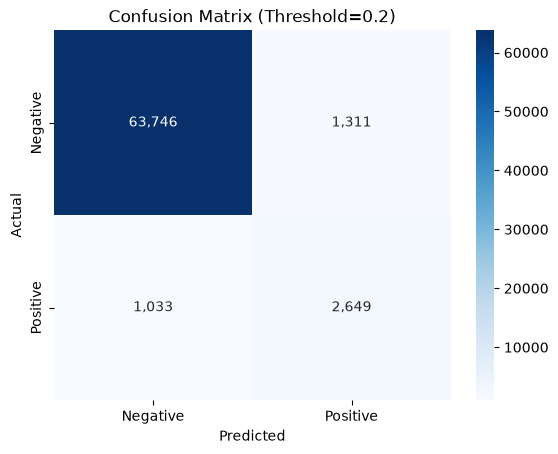

In [66]:
# Repeat Use threshold = 0.2 as best decision point
# On model with extra parameters

threshold = 0.20

proba_test2 = best_model2.predict_proba(X2_test)[:,1]

model_pred2 = (proba_test2 >= threshold).astype(int)

# Then show confusion matrix
# Now repeat heatmap/confusion matrix

cm2 = confusion_matrix(y2_test, model_pred2)

sns.heatmap(
    cm2,
    annot=True,
    fmt=",d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title(
    f"Confusion Matrix (Threshold={threshold})"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

ROC-AUC = 0.9145


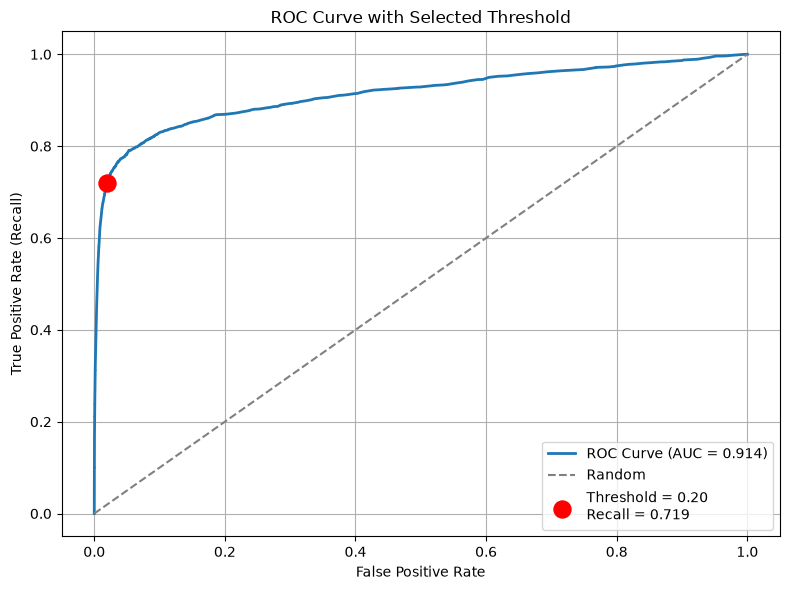

In [67]:

test_auc2 = roc_auc_score(
    y2_test,
    proba_test2
)

print(f"ROC-AUC = {test_auc2:.4f}")


# ====================================================
# ROC Curve
# ====================================================

fpr2, tpr2, thresholds2 = roc_curve(
    y2_test,
    proba_test2
)

# Find point closest to threshold=0.20
idx = np.argmin(
    np.abs(thresholds2 - threshold)
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr2,
    tpr2,
    linewidth=2,
    label=f"ROC Curve (AUC = {test_auc2:.3f})"
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Random"
)

# Threshold marker
plt.scatter(
    fpr2[idx],
    tpr2[idx],
    color="red",
    s=150,
    zorder=5,
    label=(
        f"Threshold = {thresholds2[idx]:.2f}\n"
        f"Recall = {tpr2[idx]:.3f}"
    )
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve with Selected Threshold")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [70]:
# side by side comparison

def evaluate_model(
    model,
    X_test,
    y_test,
    model_name,
    threshold=0.20
):
    # Predicted probability of positive result
    probabilities = model.predict_proba(X_test)[:, 1]

    # Convert probabilities to class predictions
    predictions = (
        probabilities >= threshold
    ).astype(int)

    # Confusion-matrix values
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1]
    ).ravel()

    return {
        "Model": model_name,
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1 score": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            probabilities
        ),
        "False negatives": fn,
        "False positives": fp
    }

In [71]:
comparison = pd.DataFrame([
    evaluate_model(
        model=best_model,
        X_test=X_test,
        y_test=y_test,
        model_name="Original model: 8 features",
        threshold=0.20
    ),

    evaluate_model(
        model=best_model2,
        X_test=X2_test,
        y_test=y2_test,
        model_name="New model: prior_7d added",
        threshold=0.20
    )
])


In [72]:
comparison.set_index("Model").round(4)

,Threshold,Precision,Recall,F1 score,ROC-AUC,False negatives,False positives
Model,,,,,,,
Original model: 8 features,0.2,0.6365,0.6980,0.6658,0.9095,1112,1468
New model: prior_7d added,0.2,0.6689,0.7194,0.6933,0.9145,1033,1311


In [ ]:
# reduced false negatives by 79 patients while simultaneously reducing false positives by 157 patients

print("Same test-set size:", len(y_test) == len(y2_test))
print("Same test indices:", y_test.index.equals(y2_test.index))
print("Same target values:", y_test.equals(y2_test))

Same test-set size: True
Same test indices: True
Same target values: True
